# Notebook 03: LBNL FCU Fault Data — Download + EDA

**Module C, Part 1.**

Real public HVAC fault data from Lawrence Berkeley National Laboratory.

Dataset: Fan Coil Unit (FCU) — fault-free + 15 fault types, year-long simulation.
Source: LBNL Fault Detection and Diagnostics Datasets (Granderson et al., 2023, Nature Scientific Data).

This notebook:
1. Downloads the FCU dataset
2. Inspects its structure
3. Explores fault patterns vs normal operation
4. Saves a clean, modelling-ready dataset for Notebook 04

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
import requests
from pathlib import Path

PROJECT_ROOT = '/content/drive/MyDrive/smart-facility-pulse'
LBNL_DIR = os.path.join(PROJECT_ROOT, 'data', 'lbnl')
LBNL_RAW_DIR = os.path.join(LBNL_DIR, 'raw')
os.makedirs(LBNL_RAW_DIR, exist_ok=True)

print(f"LBNL data directory: {LBNL_DIR}")
print(f"Raw download directory: {LBNL_RAW_DIR}")

LBNL data directory: /content/drive/MyDrive/smart-facility-pulse/data/lbnl
Raw download directory: /content/drive/MyDrive/smart-facility-pulse/data/lbnl/raw


In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = '/content/drive/MyDrive/smart-facility-pulse'
LBNL_DIR = os.path.join(PROJECT_ROOT, 'data', 'lbnl')
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'synthetic')

print(f"✓ LBNL directory: {LBNL_DIR}")
print(f"✓ Exists: {os.path.exists(LBNL_DIR)}")

# If a zip file is present, list it (we'll extract in next cell if needed)
if os.path.exists(LBNL_DIR):
    contents = os.listdir(LBNL_DIR)
    zips = [f for f in contents if f.endswith('.zip')]
    if zips:
        print(f"\n⚠️  Found {len(zips)} zip file(s) — these may need extraction:")
        for z in zips:
            print(f"   • {z}")

✓ LBNL directory: /content/drive/MyDrive/smart-facility-pulse/data/lbnl
✓ Exists: True


In [15]:
def explore_directory(root_dir, max_depth=4):
    """Recursively list contents with file types and sizes."""
    findings = {
        'csv_files': [],
        'other_files': [],
        'folders': [],
        'total_size_mb': 0,
    }

    for dirpath, dirnames, filenames in os.walk(root_dir):
        rel_depth = dirpath[len(root_dir):].count(os.sep)
        if rel_depth >= max_depth:
            continue

        rel_dir = os.path.relpath(dirpath, root_dir) if dirpath != root_dir else '.'
        if rel_dir != '.':
            findings['folders'].append(rel_dir)

        for fname in filenames:
            fpath = os.path.join(dirpath, fname)
            size_mb = os.path.getsize(fpath) / (1024 * 1024)
            findings['total_size_mb'] += size_mb
            entry = {
                'folder': rel_dir,
                'filename': fname,
                'size_mb': round(size_mb, 2),
                'full_path': fpath,
            }
            if fname.lower().endswith('.csv'):
                findings['csv_files'].append(entry)
            else:
                findings['other_files'].append(entry)

    return findings

findings = explore_directory(LBNL_DIR)

print("=" * 70)
print(f"LBNL FOLDER DISCOVERY")
print("=" * 70)
print(f"Root: {LBNL_DIR}")
print(f"Total size: {findings['total_size_mb']:.1f} MB")
print(f"Subfolders: {len(findings['folders'])}")
print(f"CSV files:  {len(findings['csv_files'])}")
print(f"Other files: {len(findings['other_files'])}")

if findings['folders']:
    print(f"\n📁 SUBFOLDERS:")
    for f in findings['folders'][:30]:
        print(f"   {f}")
    if len(findings['folders']) > 30:
        print(f"   ... and {len(findings['folders']) - 30} more")

if findings['csv_files']:
    print(f"\n📊 CSV FILES (first 40):")
    csv_df = pd.DataFrame(findings['csv_files'])
    csv_df = csv_df.sort_values('filename').reset_index(drop=True)
    print(csv_df[['folder', 'filename', 'size_mb']].head(40).to_string())
    if len(csv_df) > 40:
        print(f"\n   ... and {len(csv_df) - 40} more CSV files")

if findings['other_files']:
    print(f"\n📄 NON-CSV FILES:")
    for f in findings['other_files'][:15]:
        print(f"   [{f['size_mb']:>6.2f} MB] {f['folder']}/{f['filename']}")

LBNL FOLDER DISCOVERY
Root: /content/drive/MyDrive/smart-facility-pulse/data/lbnl
Total size: 3938.3 MB
Subfolders: 1
CSV files:  49
Other files: 0

📁 SUBFOLDERS:
   raw

📊 CSV FILES (first 40):
   folder                                    filename  size_mb
0     raw              FCU_Control_CoolingReverse.csv    80.02
1     raw              FCU_Control_HeatingReverse.csv    81.80
2     raw                    FCU_Control_Unstable.csv    80.35
3     raw                   FCU_FanOutletBlockage.csv    79.78
4     raw                           FCU_FaultFree.csv    80.40
5     raw               FCU_FilterRestriction_10%.csv    79.77
6     raw               FCU_FilterRestriction_20%.csv    79.93
7     raw               FCU_FilterRestriction_50%.csv    79.92
8     raw       FCU_Fouling_Cooling_Airside_Minor.csv    80.11
9     raw    FCU_Fouling_Cooling_Airside_Moderate.csv    79.94
10    raw      FCU_Fouling_Cooling_Airside_Severe.csv    80.09
11    raw     FCU_Fouling_Cooling_Waterside_Minor

In [12]:
if findings['csv_files']:
    # Pick the first CSV alphabetically — usually a fault-free or low-severity file
    first_csv = sorted(findings['csv_files'], key=lambda x: x['filename'])[0]
    sample_path = first_csv['full_path']

    print(f"Inspecting: {first_csv['filename']}")
    print(f"Size: {first_csv['size_mb']} MB")
    print("-" * 70)

    # Read just first 5 rows to see schema without loading the whole thing
    sample = pd.read_csv(sample_path, nrows=5)
    print(f"\nShape (first 5 rows): {sample.shape}")
    print(f"\nColumns ({len(sample.columns)}):")
    for i, col in enumerate(sample.columns):
        print(f"   {i+1:>3}. {col}")

    print(f"\n📋 First 5 rows:")
    print(sample.to_string())

    # Get total row count without loading everything
    print(f"\nCounting total rows in {first_csv['filename']}...")
    with open(sample_path) as f:
        total_rows = sum(1 for _ in f) - 1
    print(f"Total rows: {total_rows:,}")
else:
    print("⚠️  No CSV files found in LBNL directory.")
    print("   Check that files are at: " + LBNL_DIR)

Inspecting: FCU_Control_CoolingReverse.csv
Size: 80.02 MB
----------------------------------------------------------------------

Shape (first 5 rows): (5, 30)

Columns (30):
     1. Datetime
     2. FCU_CTRL
     3. FAN_CTRL
     4. RM_TEMP
     5. RMCLGSPT
     6. RMHTGSPT
     7. FCU_MAT
     8. FCU_DAT
     9. FCU_RAT
    10. FCU_CVLV
    11. FCU_CVLV_DM
    12. FCU_CLG_GPM
    13. FCU_CLG_EWT
    14. FCU_CLG_RWT
    15. FCU_HVLV
    16. FCU_HVLV_DM
    17. FCU_HTG_GPM
    18. FCU_HTG_EWT
    19. FCU_HTG_RWT
    20. FCU_DA_CFM
    21. FCU_OA_CFM
    22. FCU_DMPR
    23. FCU_DMPR_DM
    24. FCU_SPD
    25. FCU_OAT
    26. FCU_WAT
    27. FCU_MA_HUMD
    28. FCU_OA_HUMD
    29. FCU_DA_HUMD
    30. FCU_RA_HUMD

📋 First 5 rows:
           Datetime  FCU_CTRL  FAN_CTRL  RM_TEMP  RMCLGSPT  RMHTGSPT  FCU_MAT  FCU_DAT  FCU_RAT  FCU_CVLV  FCU_CVLV_DM  FCU_CLG_GPM  FCU_CLG_EWT  FCU_CLG_RWT  FCU_HVLV  FCU_HVLV_DM  FCU_HTG_GPM  FCU_HTG_EWT  FCU_HTG_RWT  FCU_DA_CFM  FCU_OA_CFM  FCU_DMPR  FCU_DMP

# Feature Selection and Modelling

In [16]:
# 18 files chosen for Dubai/cooling-only FM relevance
# Each entry: (filename, fault_label, fault_type, severity)
SELECTED_FAULTS = [
    # Baseline
    ('FCU_FaultFree.csv',                          0, 'fault_free',                'none'),

    # Cooling coil fouling (air-side) — clogged AC coil from dust/debris
    ('FCU_Fouling_Cooling_Airside_Minor.csv',      1, 'cooling_fouling_airside',   'minor'),
    ('FCU_Fouling_Cooling_Airside_Moderate.csv',   1, 'cooling_fouling_airside',   'moderate'),
    ('FCU_Fouling_Cooling_Airside_Severe.csv',     1, 'cooling_fouling_airside',   'severe'),

    # Cooling coil fouling (water-side) — chilled water side scaling
    ('FCU_Fouling_Cooling_Waterside_Minor.csv',    1, 'cooling_fouling_waterside', 'minor'),
    ('FCU_Fouling_Cooling_Waterside_Moderate.csv', 1, 'cooling_fouling_waterside', 'moderate'),
    ('FCU_Fouling_Cooling_Waterside_Severe.csv',   1, 'cooling_fouling_waterside', 'severe'),

    # Filter restriction — clogged air filter (the #1 real-world FM issue)
    ('FCU_FilterRestriction_10%.csv',              1, 'filter_restriction',        'minor'),
    ('FCU_FilterRestriction_20%.csv',              1, 'filter_restriction',        'moderate'),
    ('FCU_FilterRestriction_50%.csv',              1, 'filter_restriction',        'severe'),

    # Cooling valve faults
    ('FCU_VLVStuck_Cooling_0.csv',                 1, 'cooling_valve_stuck',       'closed'),
    ('FCU_VLVStuck_Cooling_100.csv',               1, 'cooling_valve_stuck',       'open'),
    ('FCU_VLVLeak_Cooling_50.csv',                 1, 'cooling_valve_leak',        'moderate'),

    # Airflow / ventilation faults
    ('FCU_OABlockage.csv',                         1, 'oa_inlet_blockage',         'severe'),
    ('FCU_FanOutletBlockage.csv',                  1, 'fan_outlet_blockage',       'severe'),

    # Sensor & control faults
    ('FCU_SensorBias_RMTemp_+2C.csv',              1, 'sensor_bias',               '+2C'),
    ('FCU_Control_Unstable.csv',                   1, 'control_unstable',          'na'),
    ('FCU_Control_CoolingReverse.csv',             1, 'control_reverse',           'na'),
]

# Columns to drop (heating-only, irrelevant for Dubai)
DROP_COLS = ['RMHTGSPT', 'FCU_HVLV', 'FCU_HVLV_DM',
             'FCU_HTG_GPM', 'FCU_HTG_EWT', 'FCU_HTG_RWT']

# Temperature columns (in °F → will convert to °C)
TEMP_COLS_F = ['RM_TEMP', 'RMCLGSPT', 'FCU_MAT', 'FCU_DAT', 'FCU_RAT',
               'FCU_CLG_EWT', 'FCU_CLG_RWT', 'FCU_OAT']

print(f"✓ Selected {len(SELECTED_FAULTS)} files (1 healthy + {len(SELECTED_FAULTS)-1} fault scenarios)")
print(f"✓ Fault types covered: {len(set(f[2] for f in SELECTED_FAULTS))}")
print(f"✓ Dropping {len(DROP_COLS)} heating-only columns")

# Quick label distribution
label_counts = pd.Series([f[1] for f in SELECTED_FAULTS]).value_counts()
print(f"\nLabel split:")
print(f"  Healthy (0): {label_counts.get(0, 0)} files")
print(f"  Faulty  (1): {label_counts.get(1, 0)} files")

✓ Selected 18 files (1 healthy + 17 fault scenarios)
✓ Fault types covered: 11
✓ Dropping 6 heating-only columns

Label split:
  Healthy (0): 1 files
  Faulty  (1): 17 files


In [17]:
def f_to_c(f):
    """Convert Fahrenheit to Celsius."""
    return (f - 32) * 5 / 9

def load_and_downsample(filepath, fault_label, fault_type, severity):
    """
    Load one LBNL FCU CSV, downsample to hourly, convert °F→°C,
    drop heating columns, and tag with labels.
    """
    # Read full minute-level file
    df = pd.read_csv(filepath, parse_dates=['Datetime'],
                     date_format='%m/%d/%Y %H:%M')
    df = df.set_index('Datetime')

    # Drop heating-only columns
    df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

    # Downsample to hourly mean (525,600 → 8,760 rows)
    df_hourly = df.resample('1h').mean()

    # Convert all temperature columns from °F to °C
    for col in TEMP_COLS_F:
        if col in df_hourly.columns:
            df_hourly[col] = f_to_c(df_hourly[col]).round(2)

    # Round other floats for cleaner storage
    for col in df_hourly.columns:
        if df_hourly[col].dtype == 'float64':
            df_hourly[col] = df_hourly[col].round(3)

    # Add labels
    df_hourly['fault_label'] = fault_label
    df_hourly['fault_type'] = fault_type
    df_hourly['severity'] = severity

    # Reset index so Datetime is a regular column
    df_hourly = df_hourly.reset_index()

    return df_hourly

# Test on one file before processing all
print("Testing loader on one file (FCU_FaultFree.csv)...")
test_path = os.path.join(LBNL_DIR, 'raw', 'FCU_FaultFree.csv')
test_df = load_and_downsample(test_path, 0, 'fault_free', 'none')
print(f"✓ Loaded shape: {test_df.shape}")
print(f"✓ Columns: {list(test_df.columns)}")
print(f"\nFirst 3 rows:")
test_df.head(3)

Testing loader on one file (FCU_FaultFree.csv)...
✓ Loaded shape: (8760, 27)
✓ Columns: ['Datetime', 'FCU_CTRL', 'FAN_CTRL', 'RM_TEMP', 'RMCLGSPT', 'FCU_MAT', 'FCU_DAT', 'FCU_RAT', 'FCU_CVLV', 'FCU_CVLV_DM', 'FCU_CLG_GPM', 'FCU_CLG_EWT', 'FCU_CLG_RWT', 'FCU_DA_CFM', 'FCU_OA_CFM', 'FCU_DMPR', 'FCU_DMPR_DM', 'FCU_SPD', 'FCU_OAT', 'FCU_WAT', 'FCU_MA_HUMD', 'FCU_OA_HUMD', 'FCU_DA_HUMD', 'FCU_RA_HUMD', 'fault_label', 'fault_type', 'severity']

First 3 rows:


,Datetime,FCU_CTRL,FAN_CTRL,RM_TEMP,RMCLGSPT,FCU_MAT,FCU_DAT,FCU_RAT,FCU_CVLV,FCU_CVLV_DM,...,FCU_SPD,FCU_OAT,FCU_WAT,FCU_MA_HUMD,FCU_OA_HUMD,FCU_DA_HUMD,FCU_RA_HUMD,fault_label,fault_type,severity
0,2018-01-01 00:00:00,2.0,1.0,22.22,29.44,9.42,20.47,22.22,0.0,0.0,...,0.0,-3.38,0.0,60.110,56.362,49.398,43.501,0,fault_free,none
1,2018-01-01 01:00:00,2.0,1.0,21.79,29.44,9.37,16.16,21.79,0.0,0.0,...,0.0,-3.06,0.0,59.217,55.020,64.543,43.567,0,fault_free,none
2,2018-01-01 02:00:00,2.0,1.0,21.60,29.44,9.41,13.58,21.60,0.0,0.0,...,0.0,-2.78,0.0,58.024,53.930,75.975,43.056,0,fault_free,none


In [18]:
import time

processed_dfs = []
start_time = time.time()

print(f"Processing {len(SELECTED_FAULTS)} files...\n")
print(f"{'#':<4}{'File':<48}{'Rows':>8}{'Time':>8}")
print("-" * 70)

for i, (fname, label, ftype, severity) in enumerate(SELECTED_FAULTS, 1):
    file_start = time.time()
    fpath = os.path.join(LBNL_DIR, 'raw', fname)

    if not os.path.exists(fpath):
        print(f"{i:<4}{fname:<48}{'MISSING':>8}")
        continue

    try:
        df = load_and_downsample(fpath, label, ftype, severity)
        processed_dfs.append(df)
        elapsed = time.time() - file_start
        print(f"{i:<4}{fname:<48}{len(df):>8,}{elapsed:>7.1f}s")
    except Exception as e:
        print(f"{i:<4}{fname:<48}  ERROR: {str(e)[:30]}")

# Combine all into single dataset
fcu_df = pd.concat(processed_dfs, ignore_index=True)
total_time = time.time() - start_time

print("-" * 70)
print(f"\n✓ Total processing time: {total_time:.1f}s ({total_time/60:.1f} min)")
print(f"✓ Combined dataset shape: {fcu_df.shape}")
print(f"✓ Memory footprint: {fcu_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Processing 18 files...

#   File                                                Rows    Time
----------------------------------------------------------------------
1   FCU_FaultFree.csv                                  8,760    5.0s
2   FCU_Fouling_Cooling_Airside_Minor.csv              8,760    4.9s
3   FCU_Fouling_Cooling_Airside_Moderate.csv           8,760    6.5s
4   FCU_Fouling_Cooling_Airside_Severe.csv             8,760    5.0s
5   FCU_Fouling_Cooling_Waterside_Minor.csv            8,760    6.9s
6   FCU_Fouling_Cooling_Waterside_Moderate.csv         8,760    5.2s
7   FCU_Fouling_Cooling_Waterside_Severe.csv           8,760    5.2s
8   FCU_FilterRestriction_10%.csv                      8,760    6.7s
9   FCU_FilterRestriction_20%.csv                      8,760    4.9s
10  FCU_FilterRestriction_50%.csv                      8,760    6.3s
11  FCU_VLVStuck_Cooling_0.csv                         8,760    5.8s
12  FCU_VLVStuck_Cooling_100.csv                       8,760    4.8s
13  FCU_

In [19]:
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

# Binary label distribution
print("\n📌 Binary fault label distribution:")
label_dist = fcu_df['fault_label'].value_counts()
print(f"   Healthy (0): {label_dist.get(0, 0):>7,} rows  ({label_dist.get(0, 0)/len(fcu_df)*100:.1f}%)")
print(f"   Faulty  (1): {label_dist.get(1, 0):>7,} rows  ({label_dist.get(1, 0)/len(fcu_df)*100:.1f}%)")

# Multi-class fault type distribution
print("\n📌 Fault type distribution:")
type_dist = fcu_df['fault_type'].value_counts()
for ftype, count in type_dist.items():
    print(f"   {ftype:<32} {count:>7,}")

# Quick check: missing values
print(f"\n📌 Missing values: {fcu_df.isnull().sum().sum()}")

# Time range
print(f"\n📌 Time range: {fcu_df['Datetime'].min()} → {fcu_df['Datetime'].max()}")

# Sample stats — RM_TEMP for healthy vs faulty
print(f"\n📌 Room temperature stats by class (after F→C conversion):")
print(fcu_df.groupby('fault_label')['RM_TEMP'].describe()[['mean', 'std', 'min', 'max']].round(2))

DATASET SUMMARY

📌 Binary fault label distribution:
   Healthy (0):   8,760 rows  (5.6%)
   Faulty  (1): 148,920 rows  (94.4%)

📌 Fault type distribution:
   cooling_fouling_airside           26,280
   cooling_fouling_waterside         26,280
   filter_restriction                26,280
   cooling_valve_stuck               17,520
   fault_free                         8,760
   cooling_valve_leak                 8,760
   oa_inlet_blockage                  8,760
   fan_outlet_blockage                8,760
   sensor_bias                        8,760
   control_unstable                   8,760
   control_reverse                    8,760

📌 Missing values: 0

📌 Time range: 2018-01-01 00:00:00 → 2018-12-31 23:00:00

📌 Room temperature stats by class (after F→C conversion):
              mean   std    min    max
fault_label                           
0            21.50  3.08  12.02  29.76
1            21.66  3.70  -7.28  39.59


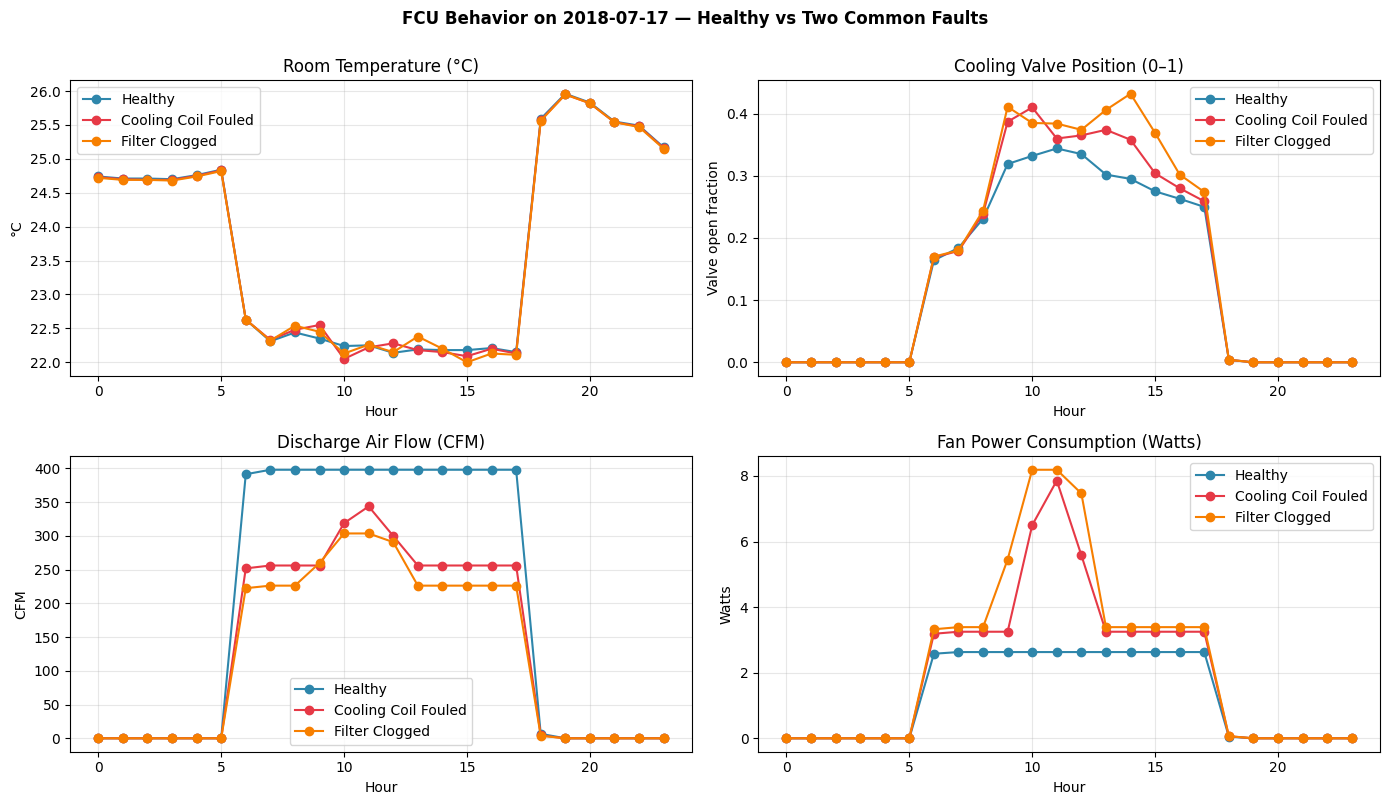

In [22]:
# Pick a hot summer day (July) for clearest cooling-mode signal
target_date = '2018-07-17'

# Get one day of data for 3 scenarios
healthy = fcu_df[(fcu_df['fault_type'] == 'fault_free') &
                 (fcu_df['Datetime'].astype(str).str.startswith(target_date))]
fouling = fcu_df[(fcu_df['fault_type'] == 'cooling_fouling_airside') &
                 (fcu_df['severity'] == 'severe') &
                 (fcu_df['Datetime'].astype(str).str.startswith(target_date))]
filter_clog = fcu_df[(fcu_df['fault_type'] == 'filter_restriction') &
                     (fcu_df['severity'] == 'severe') &
                     (fcu_df['Datetime'].astype(str).str.startswith(target_date))]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Room temperature — should rise above setpoint when AC is failing
ax = axes[0, 0]
ax.plot(healthy['Datetime'].dt.hour, healthy['RM_TEMP'], 'o-', label='Healthy', color='#2E86AB')
ax.plot(fouling['Datetime'].dt.hour, fouling['RM_TEMP'], 'o-', label='Cooling Coil Fouled', color='#E63946')
ax.plot(filter_clog['Datetime'].dt.hour, filter_clog['RM_TEMP'], 'o-', label='Filter Clogged', color='#F77F00')
ax.set_title('Room Temperature (°C)')
ax.set_xlabel('Hour'); ax.set_ylabel('°C')
ax.legend(); ax.grid(alpha=0.3)

# 2. Cooling valve position — fouled coil → valve opens wider trying to compensate
ax = axes[0, 1]
ax.plot(healthy['Datetime'].dt.hour, healthy['FCU_CVLV'], 'o-', label='Healthy', color='#2E86AB')
ax.plot(fouling['Datetime'].dt.hour, fouling['FCU_CVLV'], 'o-', label='Cooling Coil Fouled', color='#E63946')
ax.plot(filter_clog['Datetime'].dt.hour, filter_clog['FCU_CVLV'], 'o-', label='Filter Clogged', color='#F77F00')
ax.set_title('Cooling Valve Position (0–1)')
ax.set_xlabel('Hour'); ax.set_ylabel('Valve open fraction')
ax.legend(); ax.grid(alpha=0.3)

# 3. Discharge airflow — filter restriction directly reduces airflow
ax = axes[1, 0]
ax.plot(healthy['Datetime'].dt.hour, healthy['FCU_DA_CFM'], 'o-', label='Healthy', color='#2E86AB')
ax.plot(fouling['Datetime'].dt.hour, fouling['FCU_DA_CFM'], 'o-', label='Cooling Coil Fouled', color='#E63946')
ax.plot(filter_clog['Datetime'].dt.hour, filter_clog['FCU_DA_CFM'], 'o-', label='Filter Clogged', color='#F77F00')
ax.set_title('Discharge Air Flow (CFM)')
ax.set_xlabel('Hour'); ax.set_ylabel('CFM')
ax.legend(); ax.grid(alpha=0.3)

# 4. Fan power — works harder against blockage
ax = axes[1, 1]
ax.plot(healthy['Datetime'].dt.hour, healthy['FCU_WAT'], 'o-', label='Healthy', color='#2E86AB')
ax.plot(fouling['Datetime'].dt.hour, fouling['FCU_WAT'], 'o-', label='Cooling Coil Fouled', color='#E63946')
ax.plot(filter_clog['Datetime'].dt.hour, filter_clog['FCU_WAT'], 'o-', label='Filter Clogged', color='#F77F00')
ax.set_title('Fan Power Consumption (Watts)')
ax.set_xlabel('Hour'); ax.set_ylabel('Watts')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(f'FCU Behavior on {target_date} — Healthy vs Two Common Faults',
             fontsize=12, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [21]:
output_path = os.path.join(PROJECT_ROOT, 'data', 'lbnl', 'fcu_processed.parquet')
fcu_df.to_parquet(output_path, index=False)

size_mb = os.path.getsize(output_path) / 1024**2
print(f"✓ Saved processed dataset: {output_path}")
print(f"   Rows: {len(fcu_df):,}")
print(f"   Cols: {len(fcu_df.columns)}")
print(f"   Size: {size_mb:.1f} MB")
print(f"\n✓ Module C data preparation complete.")
print(f"   Next: Notebook 04 — feature engineering + XGBoost model + SHAP")

✓ Saved processed dataset: /content/drive/MyDrive/smart-facility-pulse/data/lbnl/fcu_processed.parquet
   Rows: 157,680
   Cols: 27
   Size: 4.0 MB

✓ Module C data preparation complete.
   Next: Notebook 04 — feature engineering + XGBoost model + SHAP
